# 3 &middot; Elastic Energy Intuition

The deformation gradient \(F\) says *how* a triangle is deformed. An **elastic
energy** \(\psi(F)\) turns that into a single number: *how much* it costs.

We will **write each energy out ourselves** &mdash; one line of math each &mdash;
so nothing is hidden, then compare three classics:

* **Linear elasticity**
* **ARAP** (as-rigid-as-possible)
* **Neo-Hookean** (classical)

A good energy is **zero for rigid motions** (translation, rotation) and grows
with genuine deformation (scale, shear). We'll see linear elasticity fail the
rotation test, and Neo-Hookean blow up as a triangle is crushed flat.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
import utils
os.makedirs("media", exist_ok=True)

## The three energies, written out

All three are functions of \(F\) alone, with material constants \(\mu\) (shear)
and \(\lambda\) (bulk). Let \(I\) be the identity and \(\dim = 2\) here.

**Linear elasticity** &mdash; small-strain tensor \(\varepsilon = \tfrac12(F + F^\top) - I\):
$$ \psi = \mu\,\lVert\varepsilon\rVert_F^2 + \tfrac{\lambda}{2}\,\mathrm{tr}(\varepsilon)^2. $$

**ARAP** &mdash; \(R\) is the rotation from the polar decomposition of \(F\); it
measures the distance from the *nearest pure rotation*:
$$ \psi = \mu\,\lVert F - R\rVert_F^2. $$

**Neo-Hookean** &mdash; with \(I_C = \lVert F\rVert_F^2\) and \(J = \det F\) (the
area ratio). The \(-\mu\ln J\) term is the key one: it &rarr; \(+\infty\) as
\(J \to 0\), forbidding the material from being crushed to zero area:
$$ \psi = \tfrac{\mu}{2}(I_C - 2)\; -\; \mu\ln J\; +\; \tfrac{\lambda}{2}(\ln J)^2. $$

In [2]:
def linear_energy(F, mu=1.0, lam=1.0):
    eps = 0.5 * (F + F.T) - np.eye(2)                    # small-strain tensor
    E_shear  = mu * np.sum(eps**2)                       # deviatoric (shape) term
    E_volume = 0.5 * lam * np.trace(eps)**2             # volumetric term
    E_total  = E_shear + E_volume
    return E_total

def arap_energy(F, mu=1.0, lam=1.0):
    R = simkit.polar_svd(F[None])[0][0]                  # nearest rotation to F
    return mu * np.sum((F - R)**2)                       # single term; ARAP ignores lam

def neo_hookean_energy(F, mu=1.0, lam=1.0):
    I_C = np.sum(F**2)
    J = np.linalg.det(F)
    E_shear   = 0.5 * mu * (I_C - 2)                     # resists shearing/stretching
    E_barrier = -mu * np.log(J)                          # forbids inversion (J -> 0)
    E_volume  = 0.5 * lam * np.log(J)**2                # resists volume change
    E_total   = E_shear + E_barrier + E_volume
    return E_total

ENERGIES = {"Linear": linear_energy, "ARAP": arap_energy, "Neo-Hookean": neo_hookean_energy}

# deformation maps and a helper that evaluates all three energies over a sweep
X = np.array([[-0.5, 0.0], [0.5, 0.0], [0.0, np.sqrt(3) / 2]])
T = np.array([[0, 1, 2]])
def translate(X, t): return X + np.asarray(t, float)
def rotate(X, th):
    c, s = np.cos(th), np.sin(th); return X @ np.array([[c, -s], [s, c]]).T
def scale(X, s):     return X * np.array([s, s])
def shear(X, k):     return X @ np.array([[1.0, k], [0.0, 1.0]]).T

def sweep(states, mu=1.0, lam=1.0):
    """Energy of each model across a list of deformed triangles."""
    Fs = [simkit.deformation_gradient(X, T, U)[0] for U in states]
    return {name: np.array([fn(F, mu, lam) for F in Fs]) for name, fn in ENERGIES.items()}

## Translation costs no energy

Sliding the triangle leaves every energy flat at zero. (We fix the y-axis so the
flat line doesn't look like noise.)

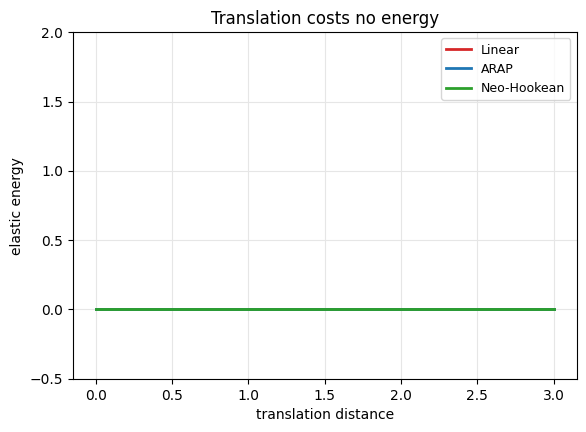


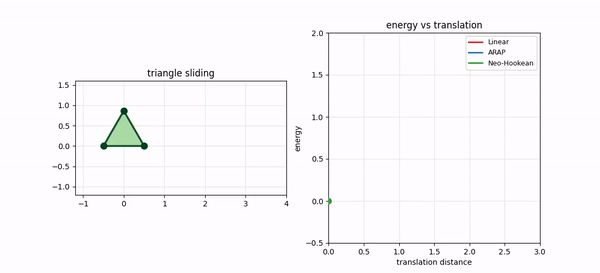

In [3]:
d = np.linspace(0, 3, 40)
states = [translate(X, [dx, 0.0]) for dx in d]
series = sweep(states)
utils.line_plot(d, series, xlabel="translation distance", ylabel="elastic energy",
                title="Translation costs no energy", ylim=(-0.5, 2.0))
plt.show()

fig, anim = utils.animate_scene_energy(states, d, series, rest=X,
    xlabel="translation distance", lims=((-1.2, 4.0), (-1.2, 1.6)),
    scene_title="triangle sliding", title="energy vs translation", fps=20,
    energy_ylim=(-0.5, 2.0))      # fixed y-axis (matches the static plot) -> flat line
utils.save_anim(anim, "media/03_translation.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## Scale: every energy grows (the intuitive case)

Uniform scaling genuinely deforms the material, so all three energies rise as we
move away from \(s = 1\).

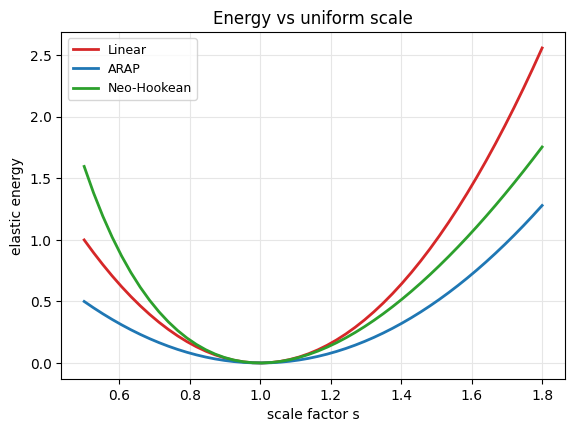


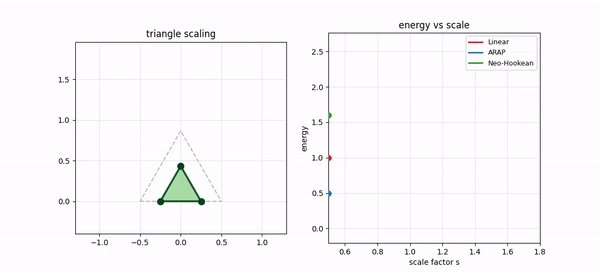

In [4]:
s = np.linspace(0.5, 1.8, 50)
states = [scale(X, si) for si in s]
series = sweep(states)
utils.line_plot(s, series, xlabel="scale factor s", ylabel="elastic energy",
                title="Energy vs uniform scale")
plt.show()
fig, anim = utils.animate_scene_energy(states, s, series, rest=X, xlabel="scale factor s",
    scene_title="triangle scaling", title="energy vs scale", fps=20)
utils.save_anim(anim, "media/03_scale.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## Shear: every energy grows too

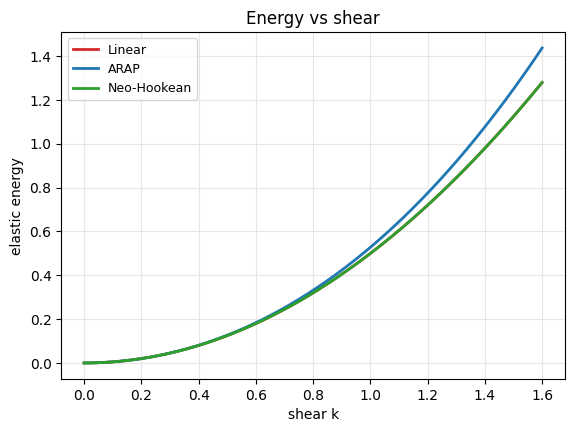


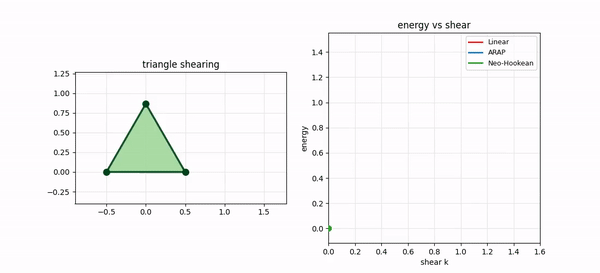

In [5]:
k = np.linspace(0.0, 1.6, 50)
states = [shear(X, ki) for ki in k]
series = sweep(states)
utils.line_plot(k, series, xlabel="shear k", ylabel="elastic energy",
                title="Energy vs shear")
plt.show()
fig, anim = utils.animate_scene_energy(states, k, series, rest=X, xlabel="shear k",
    scene_title="triangle shearing", title="energy vs shear", fps=20)
utils.save_anim(anim, "media/03_shear.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## Rotation: linear elasticity is *not* rotation-invariant

Now the surprise. Spin the triangle through a full turn. **ARAP** and
**Neo-Hookean** stay at zero &mdash; rotation is free. **Linear elasticity**
rises and falls: its small-strain tensor \(\varepsilon\) mistakes rotation for
stretch. This is why linear elasticity is only valid for *tiny* deformations.

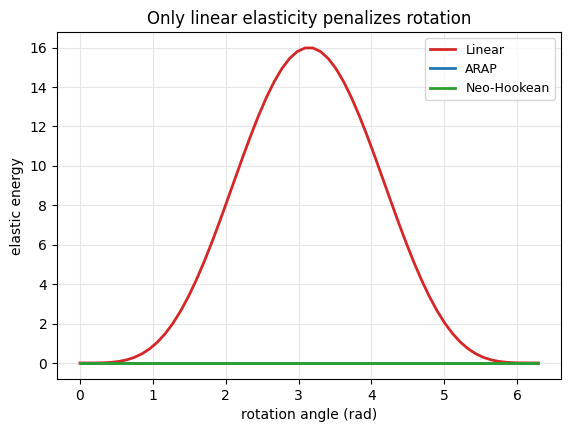


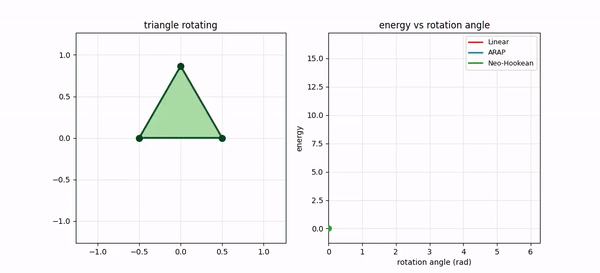

In [6]:
ang = np.linspace(0, 2 * np.pi, 60)
states = [rotate(X, a) for a in ang]
series = sweep(states)
utils.line_plot(ang, series, xlabel="rotation angle (rad)", ylabel="elastic energy",
                title="Only linear elasticity penalizes rotation")
plt.show()
fig, anim = utils.animate_scene_energy(states, ang, series, rest=X,
    xlabel="rotation angle (rad)", scene_title="triangle rotating",
    title="energy vs rotation angle", fps=20)
utils.save_anim(anim, "media/03_rotation.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## Crushing the triangle flat: Neo-Hookean &rarr; \(\infty\)

Drive the apex down toward the base so the area \(J = \det F \to 0\).

**Why didn't it explode before?** The Neo-Hookean blow-up is real but only
*logarithmic*: \(\psi \approx \tfrac{\lambda}{2}(\ln J)^2 - \mu\ln J\). Since
\(\ln J\) grows slowly, you have to (a) drive \(J\) *extremely* close to zero
**and** (b) use a stiff, nearly-incompressible material (large \(\lambda\)) for the
number to actually rocket. So here we collapse hard &mdash; \(y = y_0\,10^{-9t}\),
i.e. \(J\) down to \(\sim 10^{-9}\) &mdash; with \(\lambda = 50\). Now
**Neo-Hookean reaches \(\sim 10^4\)** and is climbing to \(+\infty\), while
**ARAP** sits at a finite plateau (it has no volume term) and **linear** stays
modest. We plot on a log axis.

det F at full collapse: 1.00e-09   Neo-Hookean energy: 10757


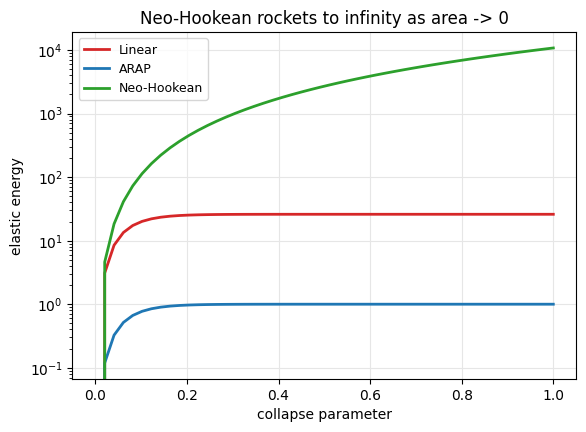


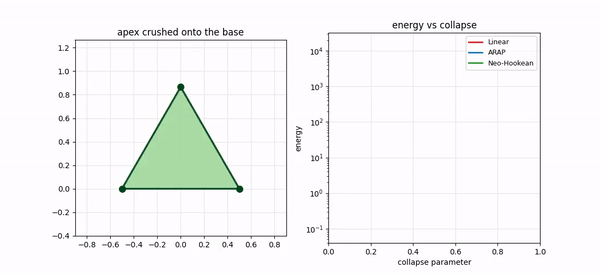

In [7]:
t = np.linspace(0, 1, 50)
y0 = X[2, 1]
def collapse_apex(frac):
    U = X.copy(); U[2, 1] = y0 * 10.0**(-9.0 * frac); return U   # hard log collapse -> J ~ 1e-9
states = [collapse_apex(f) for f in t]
series = sweep(states, mu=1.0, lam=50.0)              # nearly-incompressible: lam >> mu
Jend = np.linalg.det(simkit.deformation_gradient(X, T, states[-1])[0])
print(f"det F at full collapse: {Jend:.2e}   Neo-Hookean energy: {series['Neo-Hookean'][-1]:.0f}")

utils.line_plot(t, series, xlabel="collapse parameter", ylabel="elastic energy",
                logy=True, title="Neo-Hookean rockets to infinity as area -> 0")
plt.show()
fig, anim = utils.animate_scene_energy(states, t, series, rest=X,
    xlabel="collapse parameter", scene_title="apex crushed onto the base",
    title="energy vs collapse", logy=True, fps=18)
utils.save_anim(anim, "media/03_collapse.mp4", fps=18)
plt.close(fig)
utils.show_anim(anim)

### Takeaways
* We wrote each energy in one line: linear (strain tensor), ARAP (distance to a
  rotation), Neo-Hookean (with the \(-\mu\ln J\) inversion barrier).
* Good energies are zero for rigid motion and grow with scale/shear.
* **Linear** breaks rotation-invariance; **Neo-Hookean** diverges at collapse;
  **ARAP** saturates.

Next: minimize an energy (plus constraints) to actually *pose* a shape.